In [1]:
import ss_solver as solver
import utils 
import scan 
import plotting 


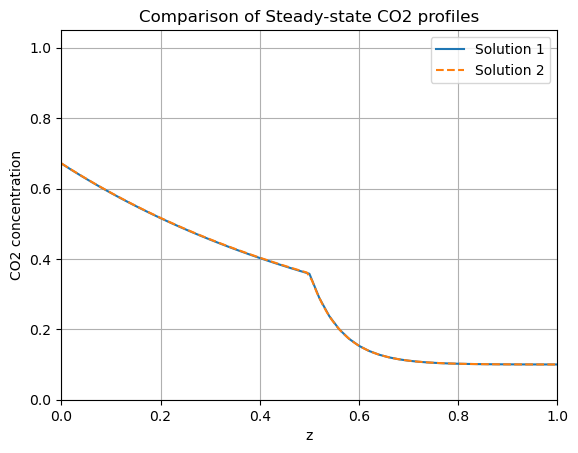

In [2]:
# show that the new solver and the previous one give the same result

import sys 
sys.path.append("../../../modules")
import leaf_model as lm 
import functools

params = [5, 5, 0.1] # tau, gamma, chi_
rho = (0.1, 0.1, 0.5)
epsilon = 0.001 

leaf = lm.Leaf(*params, rho=rho)
domain_matrix, solution_matrix = leaf.calculate_steady_state_solution()

delta = functools.partial(utils.step_down, min=leaf.deltas.min(), max=leaf.deltas.max(), offset=1-rho[2], epsilon=epsilon)
kappa = functools.partial(utils.step_up, min=leaf.kappas.min(), max=leaf.kappas.max(), offset=1-rho[2], epsilon=epsilon)

mesh, uh = solver.solver(params, delta, kappa, domain_resolution=50)
domain_dolfinx, solution_dolfinx = utils.extract_solution_from_objects(mesh, uh) 

plotting.compare_two_solutions(domain_dolfinx, solution_dolfinx, domain_matrix, solution_matrix)

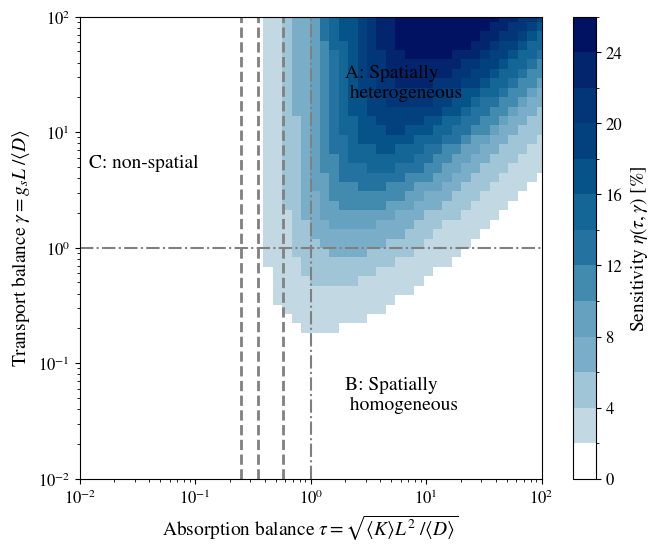

In [9]:
# reproduce figure 3C with exponential profiles for D, K 

import numpy as np

beta_range = (0.1, 3.0)
filename = "../files/sensitivities_exponential.txt"

# taus, gammas, sensitivities = scan.search_exponential(beta_range, param_num=50, comb_num=5, domain_resolution=50)
# np.savetxt(filename, sensitivities, delimiter=";")

plotting.plot_sensitivity_map(filename)
